# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

from pathlib import Path
from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

[('The Pomegranate, Apple-Tree, and Bramble', 324)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [2]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphs = graphicalizer.transform(stories)

for index, (story, graph) in enumerate(zip(stories, graphs), start=1):
    title = story.splitlines()[0]
    relation_nodes = [
        (node_id, data)
        for node_id, data in graph.nodes(data=True)
        if data.get("relation") is not None
    ]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {graph.graph['document_id']}")
    print(f"Relations: {len(relation_nodes)} | Nodes: {graph.number_of_nodes()} | Edges: {graph.number_of_edges()}")
    print("-" * 80)
    for relation_id, data in relation_nodes:
        arguments = ", ".join(
            f"{edge.get('role')}={target}"
            for _source, target, edge in graph.out_edges(relation_id, data=True)
        )
        print(f"- {data['type']}[{data['relation']}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-cb8e4e44c6b9] segment: 1 -> 1 | 0.1 ms | input_chars=324, chunk_chars=324
[document-cb8e4e44c6b9 chunk-0] summarize: 1 -> 1 | 4146.2 ms
[document-cb8e4e44c6b9 chunk-0] normalize: 1 -> 1 | 1322.2 ms
[document-cb8e4e44c6b9 chunk-0] decompose: 1 -> 4 | 3689.7 ms
[document-cb8e4e44c6b9 chunk-0] extract: 4 -> 8 | 22143.3 ms
[document-cb8e4e44c6b9] resolve: 8 -> 0 | 1020.2 ms
[document-cb8e4e44c6b9] integrate: 4 -> 8 | 1.1 ms | nodes=8, edges=8
[document-cb8e4e44c6b9] total: 1 -> 1 | 32323.5 ms | chunks=1, entities=4, relations=4, nodes=8, edges=8

Document 1/1: The Pomegranate, Apple-Tree, and Bramble
The Pomegranate, Apple-Tree, and Bramble   THE POMEGRANATE and Apple-Tree
disputed as to which was the most beautiful. When their strife was at its
height, a Bramble from the neighboring hedge lifted up its voice, and said in a
boastful tone: “Pray, my dear friends, in my presence

character: The Pomegranate
    interacts_with: character: the Apple-Tree
character: The Bramble
    located_in: place: a neighboring hedge
    interacts_with: character: The Pomegranate
    interacts_with: character: the Apple-Tree

In [3]:
graphicalizer.display(
    graphs[0],
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph display shows the reified base graph and its interpretation graph, including their mapping. Each reified base node maps to its own interpretation node, labeled by entity type; document and chunk identifiers remain in metadata. The layout uses undirected Kamada–Kawai distances by default while drawing the original directed edges.

<Axes: >

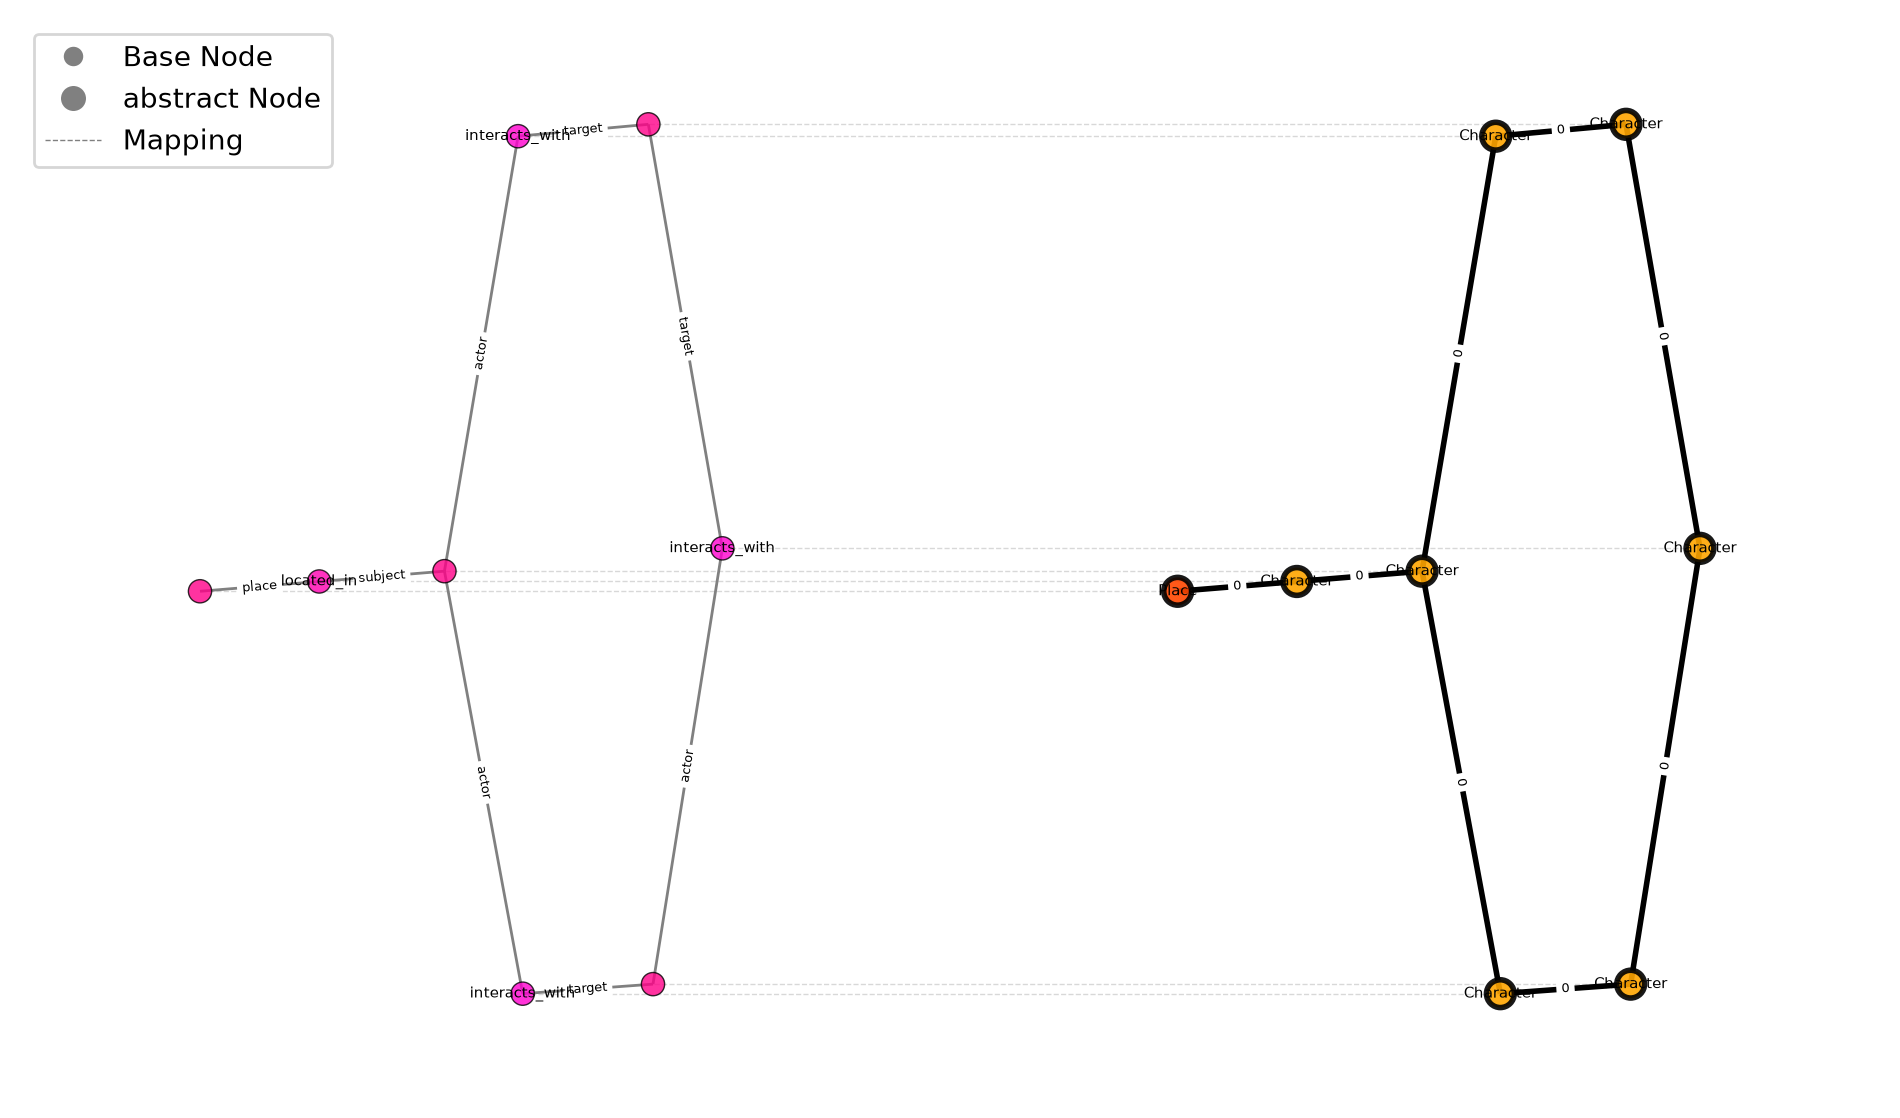

In [4]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(
    graphs[0],
    interpretation_mode="per_entity",
    preserve_direction=False,
    embed_nodes=True,
    parallel_edge_policy="first",
)

from abstractgraph.operators import *
abstract_graph = intersection_edges(abstract_graph, accept_connection_by_edge=True)
display_abstract_graph(
    abstract_graph,
    size=(12, 7),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)